<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week2/Day5/Dailychallenges/defi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Défi quotidien : Visualisation interactive des données avec Matplotlib et Seaborn

=== Aperçu ===


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10



Shape : (9994, 23)

Valeurs manquantes :
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
dtype: int64


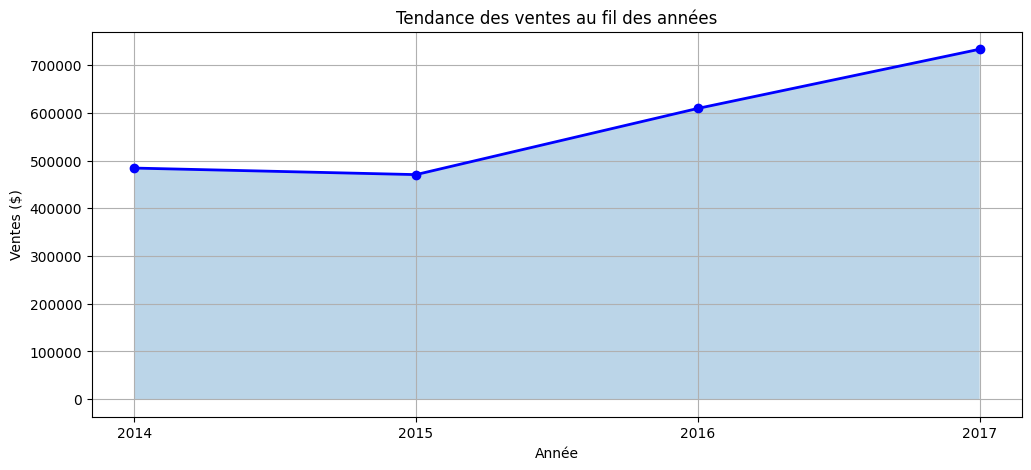

=== Ventes par année ===
Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


/tmp/ipykernel_3274/1207692181.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventes_state.values[:20],


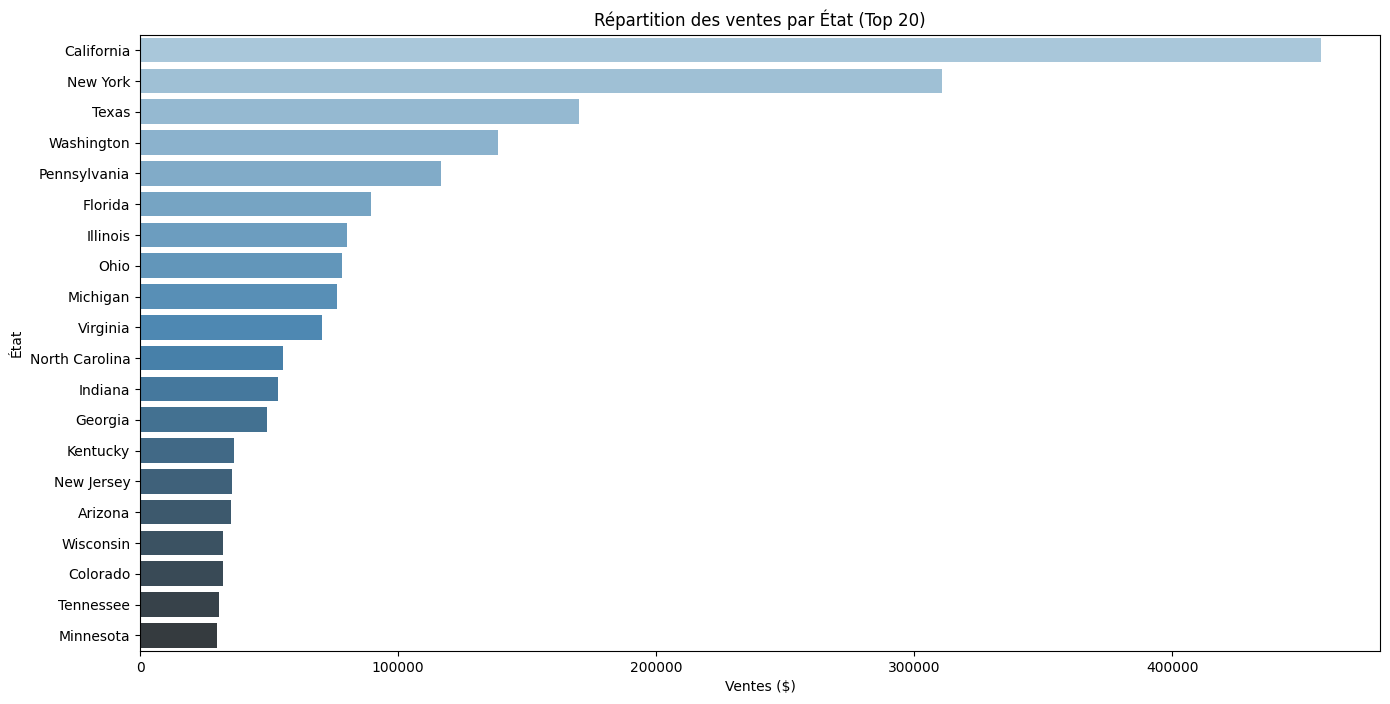

=== Top 10 États ===
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


/tmp/ipykernel_3274/1207692181.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_produits.values,


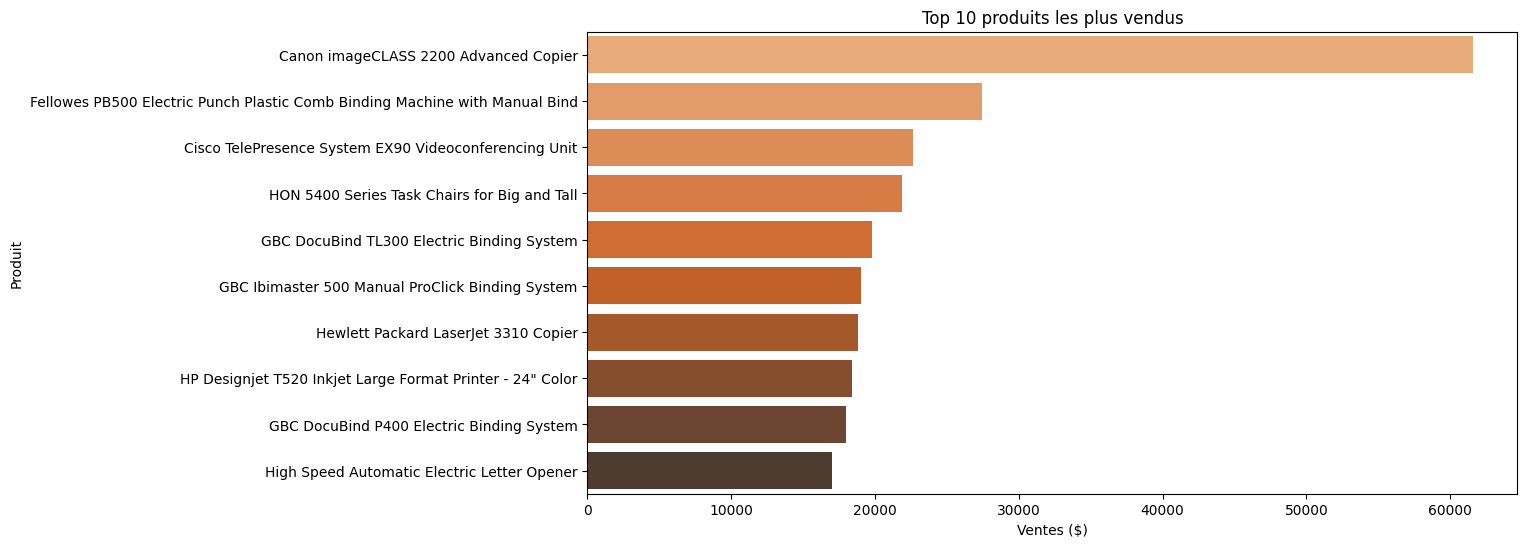

=== Top 10 produits ===
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


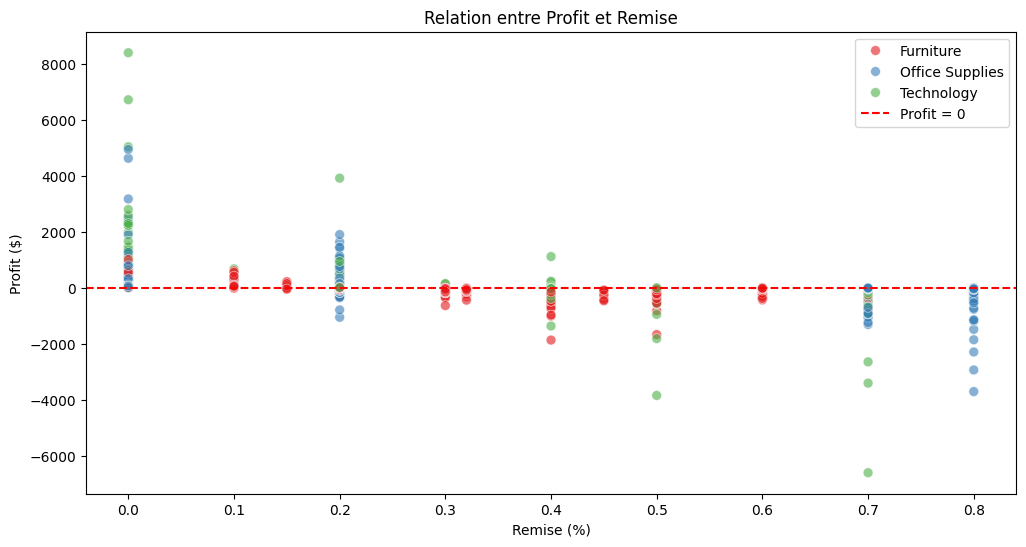

=== Corrélation Profit/Discount ===
Corrélation : -0.2195


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le dataset
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%205%20-%20Data%20Processing/W5D5%20-%20Mini-project%20-%20bis/US%20Superstore%20data.xls"

df = pd.read_excel(url)

# Prétraitement
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print("=== Aperçu ===")
display(df.head())
print(f"\nShape : {df.shape}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")

# Ventes par année
ventes_annee = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(12, 5))
plt.plot(ventes_annee.index, ventes_annee.values,
         marker='o', color='blue', linewidth=2)
plt.fill_between(ventes_annee.index, ventes_annee.values, alpha=0.3)
plt.title('Tendance des ventes au fil des années')
plt.xlabel('Année')
plt.ylabel('Ventes ($)')
plt.grid(True)
plt.xticks(ventes_annee.index)
plt.show()

print("=== Ventes par année ===")
print(ventes_annee)

# Ventes par État
ventes_state = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(16, 8))
sns.barplot(x=ventes_state.values[:20],
            y=ventes_state.index[:20],
            palette='Blues_d')
plt.title('Répartition des ventes par État (Top 20)')
plt.xlabel('Ventes ($)')
plt.ylabel('État')
plt.show()

print("=== Top 10 États ===")
print(ventes_state.head(10))

# Top 10 produits
top10_produits = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top10_produits.values,
            y=top10_produits.index,
            palette='Oranges_d')
plt.title('Top 10 produits les plus vendus')
plt.xlabel('Ventes ($)')
plt.ylabel('Produit')
plt.show()

print("=== Top 10 produits ===")
print(top10_produits)

# Relation Profit vs Discount
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category',
    palette='Set1',
    alpha=0.6,
    s=50
)
plt.title('Relation entre Profit et Remise')
plt.xlabel('Remise (%)')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='red', linestyle='--', label='Profit = 0')
plt.legend()
plt.show()

print("=== Corrélation Profit/Discount ===")
print(f"Corrélation : {df['Profit'].corr(df['Discount']):.4f}")

## Analyse comparative : Matplotlib vs Seaborn

### Matplotlib
- Plus flexible et personnalisable
- Idéal pour graphiques linéaires et temporels
- Nécessite plus de code pour un beau rendu

### Seaborn
- Plus simple et élégant
- Idéal pour graphiques statistiques
- Moins de code pour un beau rendu

### Observations clés
1. Les ventes augmentent chaque année
2. Californie et New York dominent les ventes
3. Les remises élevées réduisent les profits
4. Corrélation négative entre remise et profit

In [7]:
# Résumé final
print("=== RÉSUMÉ DÉFI ===")
print(f"Total ventes : ${df['Sales'].sum():,.2f}")
print(f"Total profit : ${df['Profit'].sum():,.2f}")
print(f"Remise moyenne : {df['Discount'].mean():.2%}")
print(f"Corrélation Profit/Discount : {df['Profit'].corr(df['Discount']):.4f}")
print(f"\n Conclusion : Plus la remise est élevée, moins le profit est important !")

=== RÉSUMÉ DÉFI ===
Total ventes : $2,297,200.86
Total profit : $286,397.02
Remise moyenne : 15.62%
Corrélation Profit/Discount : -0.2195

 Conclusion : Plus la remise est élevée, moins le profit est important !
